# Student Math Grade Analysis
This notebook explores the `student-mat.csv` dataset to understand student performance in a math course. We will clean the data, answer key analysis questions, and visualize the results.

## 1. Load Dataset & 2. Explore & Clean Data
First, we will import the necessary libraries and load the dataset. We'll then inspect its shape, data types, check for missing values, and remove any duplicate rows to ensure our data is clean.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset (Note the semicolon separator)
df = pd.read_csv('student-mat.csv', sep=';')

# 2. Explore & Clean Data
print("--- Initial Dataset Shape ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum()) # Checking for null values

# Remove duplicates
df = df.drop_duplicates()

print("\n--- Dataset Shape after dropping duplicates ---")
print(df.shape)

--- Initial Dataset Shape ---
(395, 33)

--- Data Types ---
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

--- Missing Values ---
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
s

## 3. Analysis Questions
Now we will calculate specific metrics from the dataset to answer our core questions regarding the final grade (`G3`), study habits, and demographic performance.

In [3]:
# Average final grade (G3)
avg_g3 = df['G3'].mean()
print(f"Average final grade (G3): {avg_g3:.2f}")

# How many students scored above 15?
high_scorers = df[df['G3'] > 15]
num_high_scorers = len(high_scorers)
print(f"Number of students who scored above 15: {num_high_scorers}")

# Is study time correlated with performance?
# We use the Pearson correlation coefficient between 'studytime' and 'G3'
study_grade_corr = df['studytime'].corr(df['G3'])
print(f"Correlation between study time and final grade: {study_grade_corr:.4f}")

# Which gender performs better on average?
gender_avg = df.groupby('sex')['G3'].mean()
print("\nAverage grade by gender:")
print(gender_avg)

if gender_avg['F'] > gender_avg['M']:
    print("Female students perform better on average.")
elif gender_avg['M'] > gender_avg['F']:
    print("Male students perform better on average.")
else:
    print("Both genders perform equally on average.")

Average final grade (G3): 10.42
Number of students who scored above 15: 40
Correlation between study time and final grade: 0.0978

Average grade by gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64
Male students perform better on average.


## 4. Visualizations
To better understand the distributions and relationships in our data, we will plot a histogram of grades, a scatterplot showing study time versus grades, and a bar chart comparing male and female average scores.

C:\Users\user\AppData\Local\Temp\ipykernel_11232\222731457.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='G3', data=df, ax=axes[2], estimator='mean', errorbar=None, palette='pastel')


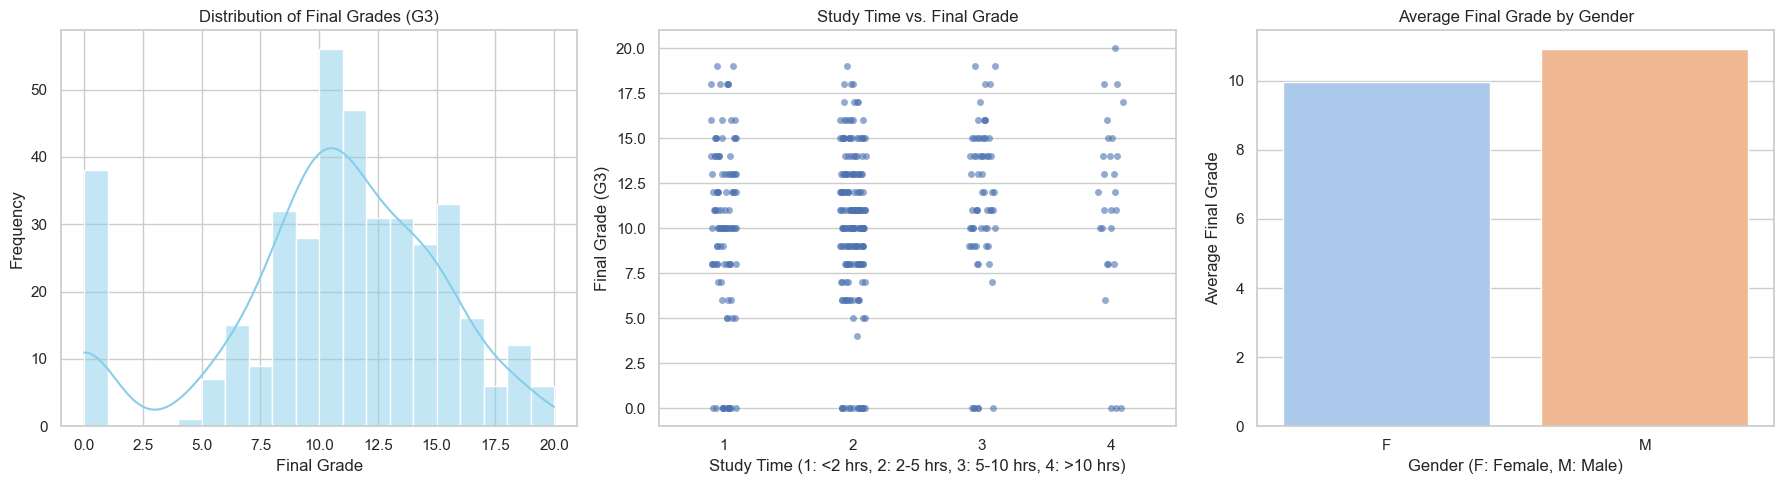

In [4]:
# Set the visual style for seaborn
sns.set_theme(style="whitegrid")

# Create a figure with subplots for our 3 visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram of grades
sns.histplot(df['G3'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Final Grades (G3)')
axes[0].set_xlabel('Final Grade')
axes[0].set_ylabel('Frequency')

# 2. Scatterplot: study time vs grades
# Note: Adding a bit of jitter (stripplot) works better than a pure scatterplot 
# because 'studytime' is an ordinal categorical variable (1, 2, 3, 4).
sns.stripplot(x='studytime', y='G3', data=df, ax=axes[1], alpha=0.6, jitter=True)
axes[1].set_title('Study Time vs. Final Grade')
axes[1].set_xlabel('Study Time (1: <2 hrs, 2: 2-5 hrs, 3: 5-10 hrs, 4: >10 hrs)')
axes[1].set_ylabel('Final Grade (G3)')

# 3. Bar chart: male vs female average score
sns.barplot(x='sex', y='G3', data=df, ax=axes[2], estimator='mean', errorbar=None, palette='pastel')
axes[2].set_title('Average Final Grade by Gender')
axes[2].set_xlabel('Gender (F: Female, M: Male)')
axes[2].set_ylabel('Average Final Grade')

# Adjust layout and display
plt.tight_layout()
plt.show()